# Visualizations for Case Study

In [3]:
dc_clip_path=r'design2code-18b-v0\evaluation_results\clip_scores.xlsx'
dc_sem_path=r'design2code-18b-v0\evaluation_results\structural_alignment_scores.xlsx'

gemini_clip_path=r'gemini\evaluation_results\gemini_clip_scores.xlsx'
gemini_sem_path=r'gemini\evaluation_results\structural_alignment_scores.xlsx'

In [4]:
import pandas as pd
dc_clip=pd.read_excel(dc_clip_path)
dc_sem=pd.read_excel(dc_sem_path)
gemini_clip=pd.read_excel(gemini_clip_path)
gemini_sem=pd.read_excel(gemini_sem_path)

In [5]:
dc_eff=r'design2code-18b-v0\design2code_18b_v0_results1.xlsx'
gemini_eff=r'gemini\gemini_results1.xlsx'
dc_eff=pd.read_excel(dc_eff)
gemini_eff=pd.read_excel(gemini_eff)

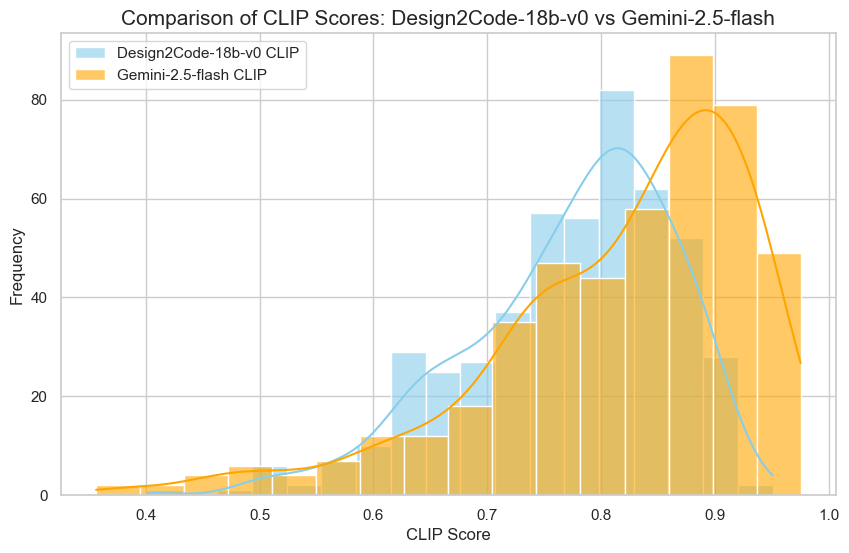

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 6))

# Plot histogram for dc_clip
sns.histplot(dc_clip['clip_score'], kde=True, color="skyblue", label='Design2Code-18b-v0 CLIP', alpha=0.6)

# Plot histogram for gemini_clip
sns.histplot(gemini_clip['clip_score'], kde=True, color="orange", label='Gemini-2.5-flash CLIP', alpha=0.6)

# Add title and labels
plt.title('Comparison of CLIP Scores: Design2Code-18b-v0 vs Gemini-2.5-flash', fontsize=15)
plt.xlabel('CLIP Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add legend
plt.legend()

# Display or save the plot
plt.show()
# If running in a script, you can use plt.savefig('clip_score_histogram.png')

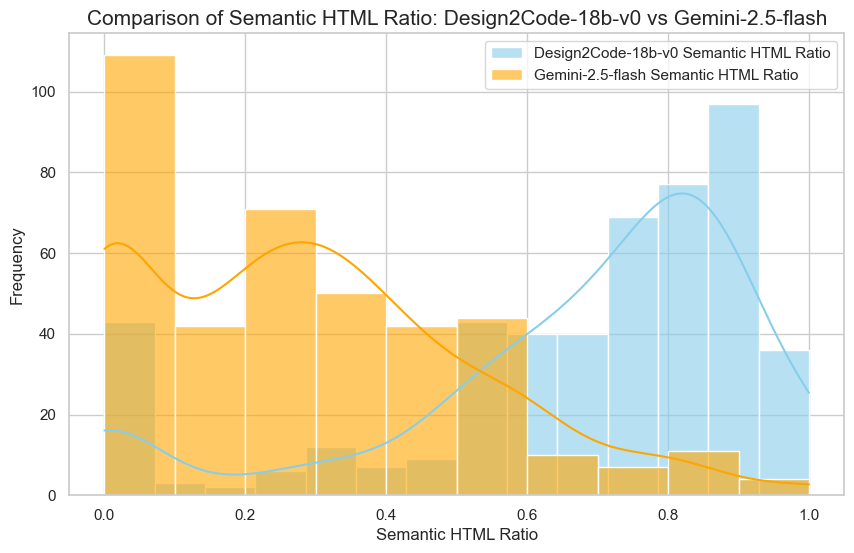

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Set plotting style
sns.set(style="whitegrid")
gemini_sem = gemini_sem[(gemini_sem['semantic_html_ratio'] != 0) | (gemini_sem['tree_edit_similarity'] != 0)]# Create figure
plt.figure(figsize=(10, 6))

# Plot histogram for dc_sem
sns.histplot(dc_sem['semantic_html_ratio'], kde=True, color="skyblue", label='Design2Code-18b-v0 Semantic HTML Ratio', alpha=0.6)

# Plot histogram for gemini_sem
sns.histplot(gemini_sem['semantic_html_ratio'], kde=True, color="orange", label='Gemini-2.5-flash Semantic HTML Ratio', alpha=0.6)

# Add title and labels
plt.title('Comparison of Semantic HTML Ratio: Design2Code-18b-v0 vs Gemini-2.5-flash', fontsize=15)
plt.xlabel('Semantic HTML Ratio', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add legend
plt.legend()

# Display or save the plot
plt.show()

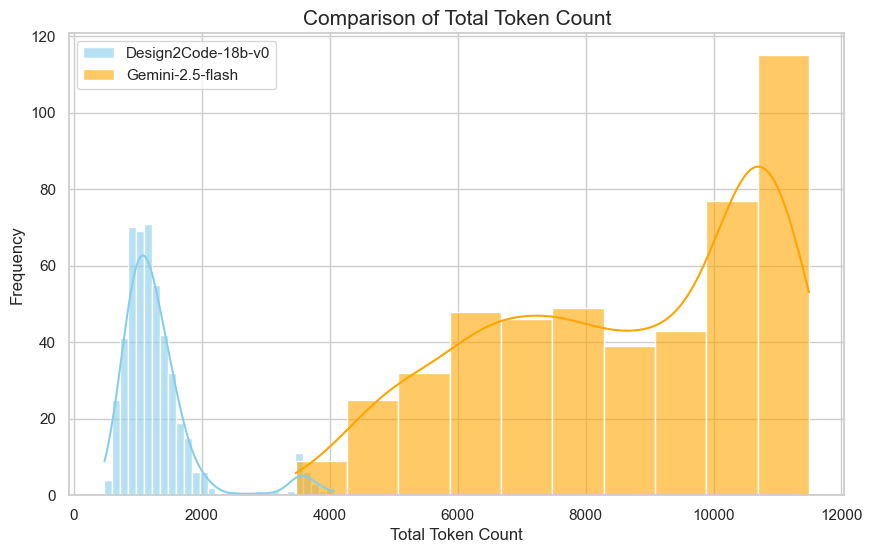

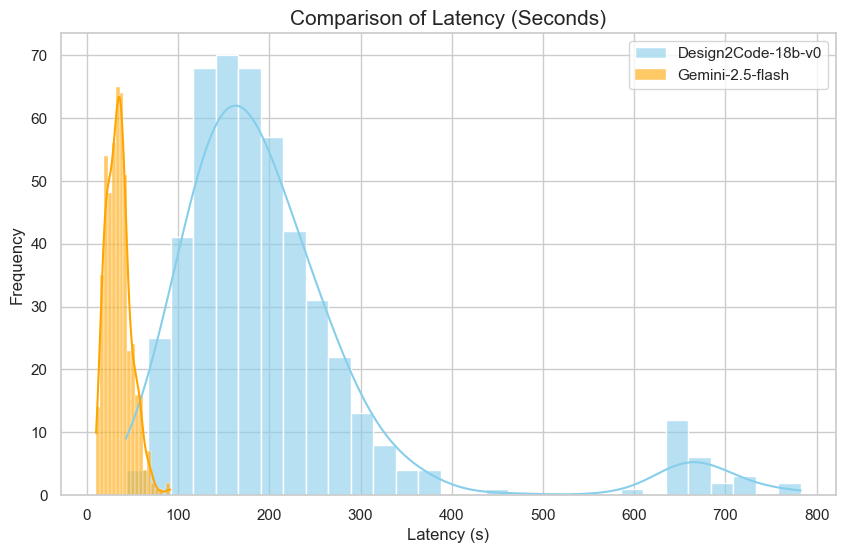

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

# --- 1. Plot comparison of total_token_count ---
plt.figure(figsize=(10, 6))
sns.histplot(dc_eff['total_token_count'], kde=True, color="skyblue", label='Design2Code-18b-v0', alpha=0.6)
sns.histplot(gemini_eff['total_token_count'], kde=True, color="orange", label='Gemini-2.5-flash', alpha=0.6)

plt.title('Comparison of Total Token Count', fontsize=15)
plt.xlabel('Total Token Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

# --- 2. Plot comparison of latency ---
plt.figure(figsize=(10, 6))
sns.histplot(dc_eff['latency'], kde=True, color="skyblue", label='Design2Code-18b-v0', alpha=0.6)
sns.histplot(gemini_eff['latency'], kde=True, color="orange", label='Gemini-2.5-flash', alpha=0.6)

plt.title('Comparison of Latency (Seconds)', fontsize=15)
plt.xlabel('Latency (s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

# Visualizations for result analysis in report

In [24]:
import pandas as pd
qwen_df=r'all_results_qwen.xlsx'
qwen_df=pd.read_excel(qwen_df)
websight_df=r'detailed_results_websight.json'
websight_df=pd.read_json(websight_df)
gemini_df=pd.concat([gemini_sem,gemini_clip,gemini_eff],axis=1)
dc_df=pd.concat([dc_sem,dc_clip,dc_eff],axis=1)



In [25]:
dc_df.drop(columns=['file_id'],inplace=True)
gemini_df.drop(columns=['file_id'],inplace=True)

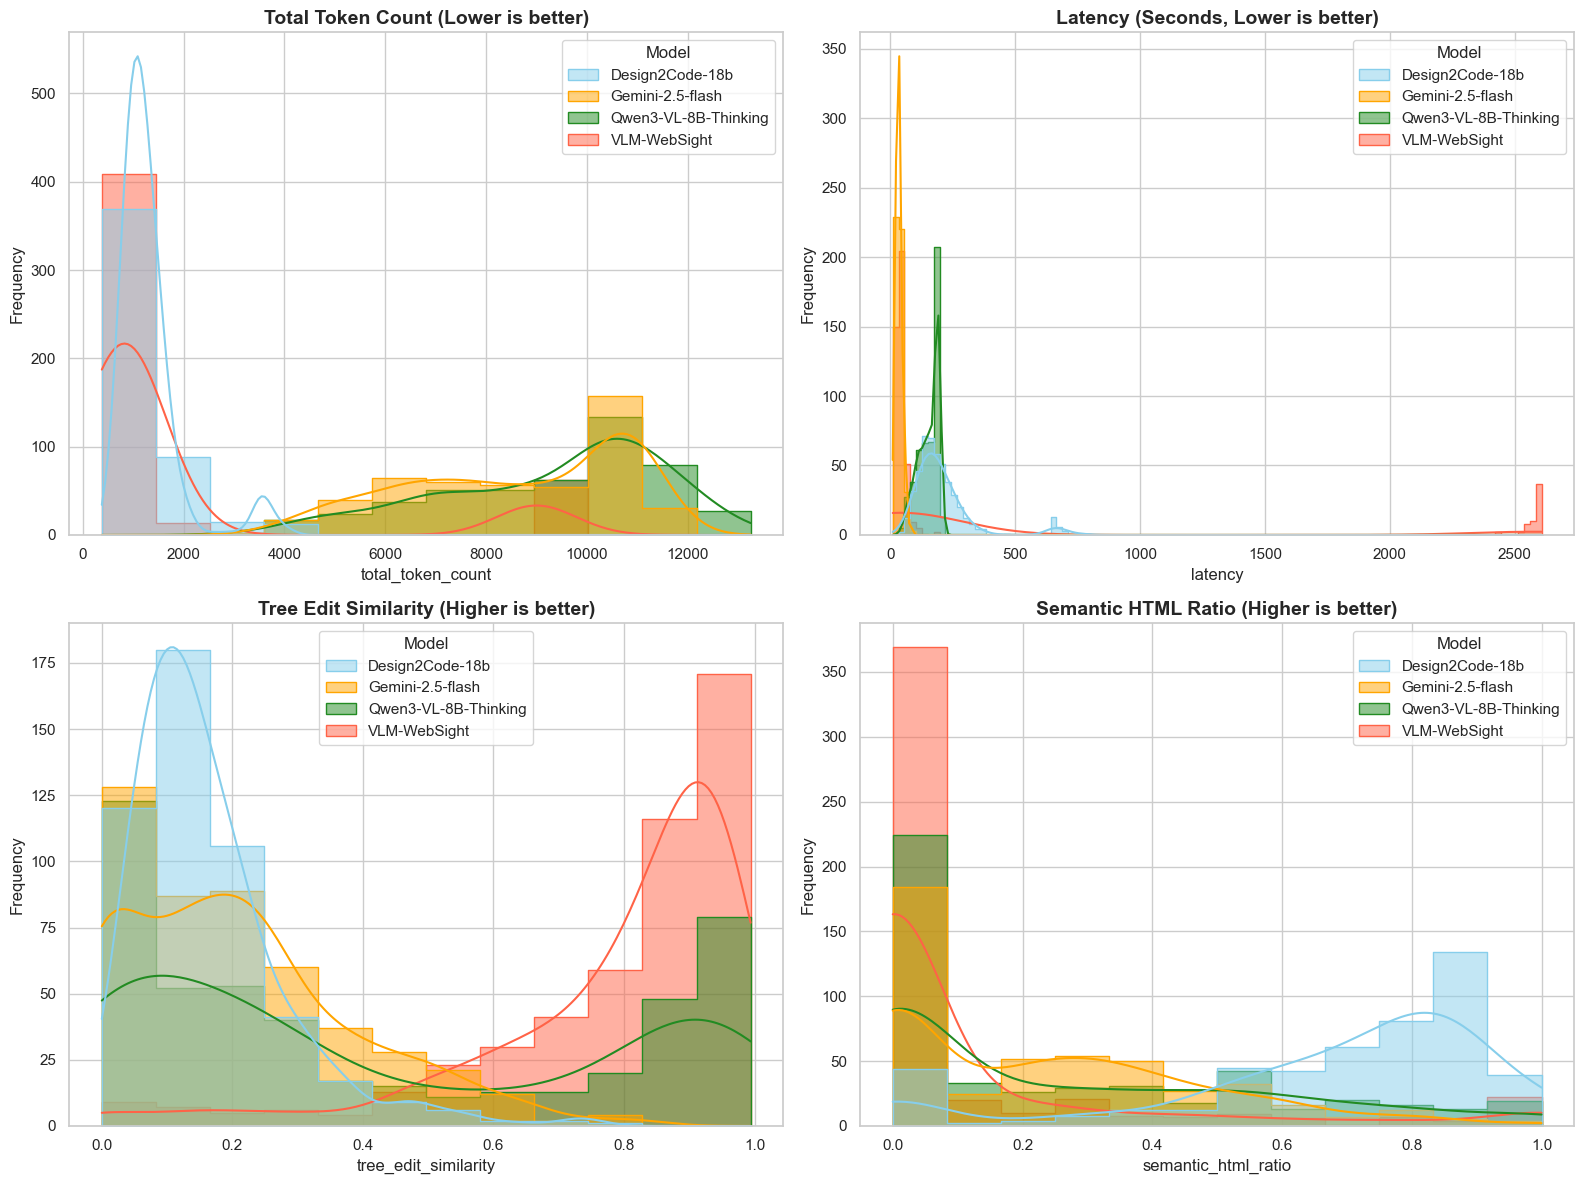

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data: ensure all DataFrames have Model identifier column
dc_df['Model'] = 'Design2Code-18b'
gemini_df['Model'] = 'Gemini-2.5-flash'
qwen_df['Model'] = 'Qwen3-VL-8B-Thinking'
websight_df['Model'] = 'VLM-WebSight'

# 2. Merge data from four models
# Note: use ignore_index=True to avoid index duplication errors encountered before
combined_df = pd.concat([dc_df, gemini_df, qwen_df, websight_df], ignore_index=True)

# 3. Define the four metrics to plot
metrics = ['total_token_count', 'latency', 'tree_edit_similarity', 'semantic_html_ratio']
titles = ['Total Token Count (Lower is better)', 
          'Latency (Seconds, Lower is better)', 
          'Tree Edit Similarity (Higher is better)', 
          'Semantic HTML Ratio (Higher is better)']

# 4. Start plotting
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Define fixed color palette to ensure consistent colors for all four models across all plots
palette = {
    'Design2Code-18b': 'skyblue',
    'Gemini-2.5-flash': 'orange',
    'Qwen3-VL-8B-Thinking': 'forestgreen',
    'VLM-WebSight': 'tomato'
}

for i, col in enumerate(metrics):
    sns.histplot(
        data=combined_df, 
        x=col, 
        hue='Model', 
        kde=True, 
        element="step",  # Use step mode for clearer visualization when multiple models overlap
        palette=palette,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent title overlap
plt.tight_layout()
plt.show()